## Day4 - Feature Engineering & Hyperparameter Tuning
In the previous days we learned how to 
- prepare  a dataset
- split a dataset into training and testing datasets.
- apply cross-validation 
- train machine learning models.
- evaluate model performance
today we are going to enhance our model by doing:
- Feature Engineering
- Hyperparameter Tuning
The key point is:
Better features for a model to learn from and hyperparameter tuning will help us build a better model.
For today notebook we will still work with the student performance Dataset used in previous days to predict **Final Exam Score**.


## By the end of this notebook we will be able to
- Develop features from  available data.
- Explain the most common methods for features engineering.
- Explain the difference  between parameter and hyperparameter.
- Use GridSearchCV to tune a machine learning model.
- Use 5-fold cross-validation in hyperparameter tuning
- Compare a tuned model with a non-tuned baseline
- Find out what features and hyperparameters were helpful in improving model performance.

## Import Libraries


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score
from math import prod
from sklearn.model_selection import RandomizedSearchCV


## Load the Dataset

In [84]:
df=pd.read_csv("student_performance_dataset.csv")

In [85]:
df.head(10)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
6,7,Male,1.5,100.0,5.0,High School,Yes,Yes,Yes,58.6,69.6,D
7,8,Male,6.2,86.4,6.0,High School,Yes,Yes,No,78.4,88.0,B
8,9,Male,5.3,81.3,6.7,Bachelors,Yes,No,No,63.8,84.4,B
9,10,Female,2.8,86.8,5.1,Bachelors,Yes,Yes,No,57.7,74.3,C


We load the dataset into pandas DataFrame ,the first rows help us understand the structure of the data.

## Check the dataset
we inspect :
- number of rows and columns.
- datatypes.
- missing values.
- numerical statistics.
This is very important before  creating a new features.

In [86]:
df.shape

(1000, 12)

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


In [88]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


## Define the target 

In [89]:
y=df["final_exam_score"]

In [90]:
x = df.drop(["final_exam_score", "final_grade"], axis=1)

### Why do we need to delete final grade?
Final_grade is directly connected to the final performance of the student using to predict final_exam_score might leak data into the model which otherwise wouldnot be known at the time of prediction it is called **data leakage** that is why it is excluded from x.
### Why do we remove student_id?
student_id is only an identifier used to distinguish students. It does not represent meaningful information about their academic performance. Keeping it could allow the model to learn accidental patterns from the ID numbers, so it is removed before training.

## Feature Engineering
### What is feature engineering?
it is a creation or modification of input variable in order to help the model learn important information.
For instance instead of using 
- number of study hours
- rate of attendance
individually we could create an input feature that describes their joint effect.
Feature engineering may sometimes outperform model selection by increasing complexity.

## Create Feature 1
we will create:
Study_Attendance_Index
This combines study hours and attendance.
### Why to add this feature?
The student who works hard but doesnot attend classes much will have a different expectation than a student who works hard and also attends class.
This feature brings together both of the data elements to a single element.

In [91]:
x["Study_Attendance_Index"]=(x["study_time_hours"]*x["attendance_percent"]/100)

## Create Feature 2
we will create:
Past_Score_Study_Ratio
This combines previous_grade and study time hours.
### Why to add this feature?
This is because it gives information about the past academic results of the student based on his study hours,this may help the model distinguish the difference efficiencies of study.
### What is the significance of adding +1?
This ensures that there is no possibility of dividing by zero when student has no hours of studying.

In [92]:
x["Past_Score_Study_Ratio"]=(x["previous_grade"]/(x["study_time_hours"]+1))

## Binning
Binning involves converting a numeric continous variable to categories
Example:
- Low study hours
- Moderate study hours
- High study hours.
This converts a continuous variable into meaningful categorical groups.


## Other Feature Engineering Methods Used Widely
### Datetime Features
Extracting meaningful information from the datetime column like:
- day
- month
- year
- day of the week
As the current dataset does not have a datetime column, therefore, no need for the creation of datetime features.
###  Scaling
Scaling puts all numerical features in a comparable range.
Some common scaling techniques include:
- StandardScaler
- MinMaxScaler
Scaling is especially important for the following types of models:
- k-NN
- SVM
- Linear Models
Random Forest is a tree-based model and does not require feature scaling.

In [93]:
x["study_level"]=pd.cut(x["study_time_hours"],bins=[-np.inf, 2, 4, 8, np.inf],
    labels=["Very Low", "Low", "Medium", "High"],)

In [94]:
x["study_level"].value_counts()

study_level
Low         467
Medium      366
Very Low    166
High          1
Name: count, dtype: int64

(While study time is expressed in numeric form we additionally include a category classification)
- less than 2 hours--> very low
- 2 hours --> Low
- 4 hours --> Medium
- 8 hours --> High

## Identify Numerical and Categorical Features
Machine Learning requires numerical inputs ,so we should separate the columns into 
- Numerical columns
- Categorical columns
Categorical will be converted into numerical values using (**One-Hot-Encoding**)

In [95]:
num_col = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_col = x.select_dtypes(include=["str", "category", "bool"]).columns.tolist()

## Preprocessing
Categorical features are converted into numerical values using one-hot encoding before training the model.

In [96]:
x = pd.get_dummies(x, columns=cat_col, drop_first=True)

## Check the new dataset
Comparision of the number of features befor and after feature engineering can be made,there should be availability of more infromation through feature engineering for the model.

In [97]:
x.shape

(1000, 17)

In [98]:
x.head()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,Study_Attendance_Index,Past_Score_Study_Ratio,gender_Male,parental_education_High School,parental_education_Masters,parental_education_PhD,internet_access_Yes,extracurricular_activities_Yes,part_time_job_Yes,study_level_Low,study_level_Medium,study_level_High
0,1,4.0,98.0,6.5,76.9,3.9200,15.380000,True,False,False,False,True,True,False,True,False,False
1,2,6.3,100.0,5.7,75.5,6.3000,10.342466,False,True,False,False,True,True,True,False,True,False
2,3,4.9,85.3,7.9,88.5,4.1797,15.000000,True,False,False,False,True,False,True,False,True,False
3,4,2.6,77.5,8.0,85.1,2.0150,23.638889,True,False,False,False,True,True,False,True,False,False
4,5,2.2,89.6,4.6,61.8,1.9712,19.312500,True,False,False,False,True,False,True,True,False,False


## Train-Test split
We will use 
- 80% for training
- 20% for testing
the test set will not be used until the final evaluation,this is how we can measure our models performance on unseen data.

In [99]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training set:",x_train.shape)
print("Testing set:",x_test.shape)

Training set: (800, 17)
Testing set: (200, 17)


## Baseline Model
Before tuning the model we need to untuned baseline , it gives us something to compare against.

In [100]:
baseline_model=RandomForestRegressor(random_state=42)

Train the model

In [101]:
baseline_model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Baseline Cross-Validation
We will use 5-fold cross-validation


In [102]:
baseline_cv_scores=cross_val_score(baseline_model,x_train,y_train,cv=5,scoring="neg_root_mean_squared_error")

Since scikit-learn calculates error metrics as negative for cross_val_score, we convert them into positive RMSE values.
RMSE is used to calculate the average magnitude of errors.
### For RMSE:
**Smaller is better**.
Thus, we will look for a tuned model that has a smaller CV RMSE.

In [103]:
baseline_rmse=-baseline_cv_scores
print("Baseline CV RMSE:",baseline_rmse)
print("Mean Baseline CV RMSE:",baseline_rmse.mean())

Baseline CV RMSE: [7.11515795 6.15215943 7.1688848  6.99471163 6.65035069]
Mean Baseline CV RMSE: 6.816252900883086


## Baseline Evaluation:
Individual CV Folds: The errors for each of the 5 folds by the model lie between 6.15 and 7.17.
Mean RMSE: 6.816  This becomes our baseline error value. Any tuned model needs to outperform this value in the future.

## Parameters VS Hyperparameters
### Parameters
Parameters are learned by the model during training.
For example, in linear regression, parameters include coefficients that are learned from the training data.
Coefficients are not selected manually.
### Hyperparameters
Hyperparameters are selected before training.
In the case of Random Forest, examples include:
- n_estimators
(Number of decision trees in the forest,**more trees can improve stability but they also increase computation time**)
- max_depth
(maximum depth of each tree , **a deeper tree can learn more complex patterns but may also overfit**)
- min_samples_split
(Minimum number of samples required to split an internal node,**a large value makes the tree less likely to create very small splits** )
These are not learned from the training data,they are instead selected before training.

In [104]:
parameter_grid={"n_estimators":[100,200],"max_depth":[5,10,None],"min_samples_split":[2,5]}

In [105]:
n_combinations = prod(len(values) for values in parameter_grid.values())
n_fits = n_combinations * 5
print("Number of hyperparameter combinations:", n_combinations)
print("Number of model fits:", n_fits)

Number of hyperparameter combinations: 12
Number of model fits: 60


## How many models will GridSearchCV Try?
our grid contains:
2 values for n_estimators × 3 values for max_depth × 2 values for min_samples_split
Therefore:
2 × 3 × 2 = 12 combinations
With 5-fold cross-validation:
12 × 5 = 60 model fits
So GridSearchCV will train and evaluate 60 models.

## Create GridSearchCV

In [106]:
random_forest= RandomForestRegressor(
    random_state=42
)
grid = GridSearchCV(
estimator=random_forest,param_grid=parameter_grid,cv=5,scoring="neg_root_mean_squared_error",n_jobs=-1
)

## Explanation
GridSearchCV will:
- Try every hyperparameter combination.
- Perform 5-fold cross-validation.
- Calculate the RMSE for each combination.
- Select the best combination.
- n_jobs=-1 allows scikit-learn to use all available CPU cores.

## Run Grid Search
It may take some time because many models are being trained.

In [107]:
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int

## RandomizedSearchCV
GridSearchCV exhausts all the combinations from the parameter grid.
If the parameter space is too big, then the process can become costly because the number of fits increases exponentially.
RandomizedSearchCV deals with this issue by sampling a finite number of random hyperparameter combinations rather than checking all the combinations.
So:
- GridSearchCV = exhaustive search
- RandomizedSearchCV = random search on a finite number of combinations
This technique works well with a large hyperparameter space.

In [108]:
random_param_grid = {
    "n_estimators": [50, 100, 150, 200, 250, 300],"max_depth": [3, 5, 7, 10, 15, 20, None],"min_samples_split": [2, 3, 5, 8, 10],"min_samples_leaf": [1, 2, 4],"max_features": [1.0, "sqrt", "log2"]
}

In [109]:
random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),param_distributions=random_param_grid,n_iter=10,cv=5,scoring="neg_root_mean_squared_error",random_state=42,n_jobs=-1)
random_search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 5, ...], 'max_features': [1.0, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSear

In [110]:
print("Best RandomizedSearchCV Parameters:")
print(random_search.best_params_)
print("Best RandomizedSearchCV CV RMSE:")
print(-random_search.best_score_)

Best RandomizedSearchCV Parameters:
{'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}
Best RandomizedSearchCV CV RMSE:
6.701761865180336


### Interpreting RandomizedSearchCV
The RandomizedSearchCV has tried a certain number of random combinations instead of trying all combinations that could have been generated.
This method is computationally effective if there is a large hyperparameter space.
If there is a small grid to be searched through, then GridSearchCV is helpful. If there is a large hyperparameter space, then RandomizedSearchCV is helpful.

## Best Hyperparameters


In [111]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


### Explanation
best_params_ indicates the hyperparameter set that achieved the highest cross-validated score.

## Best Cross-Validated Score

In [112]:
best_cv_rmse = -grid.best_score_
print(" The value of Best CV RMSE:", best_cv_rmse)

 The value of Best CV RMSE: 6.807260819004261


## Get the Best Model

In [113]:
best_model = grid.best_estimator_

Here, best_estimator_ is the Random Forest Model, which is trained by GridSearchCV.

## Compare Baseline vs Tuned Model

In [114]:
print("Baseline CV RMSE:", baseline_rmse.mean())
print("Tuned CV RMSE:", best_cv_rmse)

Baseline CV RMSE: 6.816252900883086
Tuned CV RMSE: 6.807260819004261


## Improvement Calculation


In [115]:
improvement = baseline_rmse.mean() - best_cv_rmse
print("RMSE Improvement:", improvement)

RMSE Improvement: 0.00899208187882472


### Improvement Interpretation
• Baseline RMSE > Tuned RMSE => Model improvement through tuning
• Baseline RMSE < Tuned RMSE => No improvement from tuning under current search grid.
Baseline RMSE (6.816) vs. Tuned RMSE (6.807): The Baseline RMSE is larger than the Tuned RMSE.
Net Improvement:+0.009 reduction in error, confirming a slight performance boost from hyperparameter tuning.

## Evaluate the Final Model on the Test Set
Now, we assess the selected model based on the test data, which we did not consider during the tuning process.

In [116]:
best_model.fit(x_train, y_train)
y_predict = best_model.predict(x_test)

Compute RMSE:

In [117]:
test_rmse = np.sqrt(mean_squared_error(y_test, y_predict))
print("Test RMSE value is:", test_rmse)

Test RMSE value is: 6.724760929693432


Compute R^2:

In [118]:
test_r2 = r2_score(y_test, y_predict)

print("Test R^2:", test_r2)

Test R^2: 0.5798616896385547


### Why only consider the test set now?
The test set is supposed to mimic unseen data.
Cross-validation was done on the training data set for tuning the model's parameters.After tuning, we then evaluate the performance of the model using the test data set.

# Hands-On-Lab 
## Step 1: create at least two new engineered features for a provided dataset and justify each in Markdown.
The features we made were:
### Feature 1: Study_Attendance_Index
This was based on the combination of study time and attendance.
Rationale: There is a difference between what is expected of students who are studying and attending classes compared to those who do not possess both attributes.
### Feature 2: Past_Score_Study_Ratio
Based on the combination of past score and study time.
Rationale: This is an indication of the past performance in relation to study time.
### Feature 3: Study_Level
Students can be categorized into:
* Low
* Medium
* High

## Step 2: Define a hyperparameter grid for a model from Week 3 (e.g. random forest).

In [119]:
RandomForestRegressor(random_state=42)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

The hyperparameter grid is:

In [120]:
param_grid = {"n_estimators": [100, 200],"max_depth": [5, 10, None],"min_samples_split": [2, 5]}

These hyperparameters were chosen because they affect:
Number of trees,Tree complexity,minimum samples needed for splitting

## Step 3: Run GridSearchCV with 5-fold cross-validation and report the best parameters and score.
We used:

In [121]:
GridSearchCV(estimator=random_forest,param_grid=param_grid,cv=5,scoring="neg_root_mean_squared_error")

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: i

### What this means is:
- Grid search explores all possible combinations.
- A 5-fold cross validation is performed for all combinations.
- RMSE is the criterion used for evaluation.
The winning combination is available at:

In [122]:
grid.best_params_

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

and its cross-validated score is stored in:

In [123]:
grid.best_score_

np.float64(-6.807260819004261)

## step4 : Compare the tuned model's cross-validated score against the untuned baseline from Week 3.


In [124]:
comparison = pd.DataFrame({
    "Model": ["Untuned Random Forest", "Tuned Random Forest"],
    "CV_RMSE": [baseline_rmse.mean(),best_cv_rmse]
})
comparison

,Model,CV_RMSE
0,Untuned Random Forest,6.816253
1,Tuned Random Forest,6.807261


Performance: The Tuned Random Forest achieved a lower CV RMSE (6.807) compared to the Untuned model (6.816), showing a slight improvement in predictive accuracy.

## Step 5: Document which engineered feature and which hyperparameter mattered most.
GridSearchCV stores all tested combinations in cv_results.

In [125]:
results = pd.DataFrame(grid.cv_results_)
results[["param_n_estimators","param_max_depth","param_min_samples_split","mean_test_score","rank_test_score"]].sort_values("rank_test_score").head(10)

,param_n_estimators,param_max_depth,param_min_samples_split,mean_test_score,rank_test_score
6,100,10,5,-6.807261,1
4,100,10,2,-6.808371,2
7,200,10,5,-6.809887,3
8,100,None,2,-6.816253,4
5,200,10,2,-6.816334,5
10,100,None,5,-6.817524,6
11,200,None,5,-6.830350,7
9,200,None,2,-6.836787,8
1,200,5,2,-6.868158,9
3,200,5,5,-6.868752,10


## Results Analysis
This table lets us make comparisons between the various hyperparameter combinations.
The combination which has:
**rank_test_score = 1** is the best combination.
We can examine how changes in each of the hyperparameters influenced the score.

In [126]:
results = pd.DataFrame(grid.cv_results_)
results["CV_RMSE"] = -results["mean_test_score"]
results[["param_n_estimators","param_max_depth","param_min_samples_split","CV_RMSE","rank_test_score"]
].sort_values("rank_test_score").head(10)

,param_n_estimators,param_max_depth,param_min_samples_split,CV_RMSE,rank_test_score
6,100,10,5,6.807261,1
4,100,10,2,6.808371,2
7,200,10,5,6.809887,3
8,100,None,2,6.816253,4
5,200,10,2,6.816334,5
10,100,None,5,6.817524,6
11,200,None,5,6.830350,7
9,200,None,2,6.836787,8
1,200,5,2,6.868158,9
3,200,5,5,6.868752,10


In [127]:
n_estimators_effect = (results.groupby("param_n_estimators")["CV_RMSE"].mean().sort_values())
max_depth_effect = (results.groupby("param_max_depth")["CV_RMSE"].mean().sort_values())
min_split_effect = (results.groupby("param_min_samples_split")["CV_RMSE"].mean().sort_values())
print("Average RMSE by n_estimators:")
print(n_estimators_effect)
print("Average RMSE by max_depth:")
print(max_depth_effect)
print("Average RMSE by min_samples_split:")
print(min_split_effect)

Average RMSE by n_estimators:
param_n_estimators
100    6.833492
200    6.838378
Name: CV_RMSE, dtype: float64
Average RMSE by max_depth:
param_max_depth
10    6.810463
5     6.872113
Name: CV_RMSE, dtype: float64
Average RMSE by min_samples_split:
param_min_samples_split
5    6.834799
2    6.837070
Name: CV_RMSE, dtype: float64


## Hyperparameter Analysis
The effect of each hyperparameter can be evaluated by comparing the average cross-validated RMSE across its tested values.
Because RMSE is an error metric, lower values indicate better performance.
The hyperparameter with the largest difference in average CV RMSE across its tested values can be considered the most influential within the tested grid.

In [128]:
effects = {"n_estimators": n_estimators_effect.max() - n_estimators_effect.min(),"max_depth": max_depth_effect.max() - max_depth_effect.min(),"min_samples_split": min_split_effect.max() - min_split_effect.min()}
most_influential_hyperparameter = max(effects,key=effects.get)
print("Hyperparameter effects:")
print(effects)
print("Most influential hyperparameter:")
print(most_influential_hyperparameter)

Hyperparameter effects:
{'n_estimators': np.float64(0.004886093162544292), 'max_depth': np.float64(0.06164970997678765), 'min_samples_split': np.float64(0.0022711364281269297)}
Most influential hyperparameter:
max_depth


## Feature Importance
Random Forest provides feature importance values.

In [129]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
5,Study_Attendance_Index,0.476480
4,previous_grade,0.231586
2,attendance_percent,0.064656
3,sleep_hours,0.051077
6,Past_Score_Study_Ratio,0.042391
0,student_id,0.039949
11,internet_access_Yes,0.025412
1,study_time_hours,0.022678
13,part_time_job_Yes,0.022299
12,extracurricular_activities_Yes,0.005881


## Visualize Feature Importance


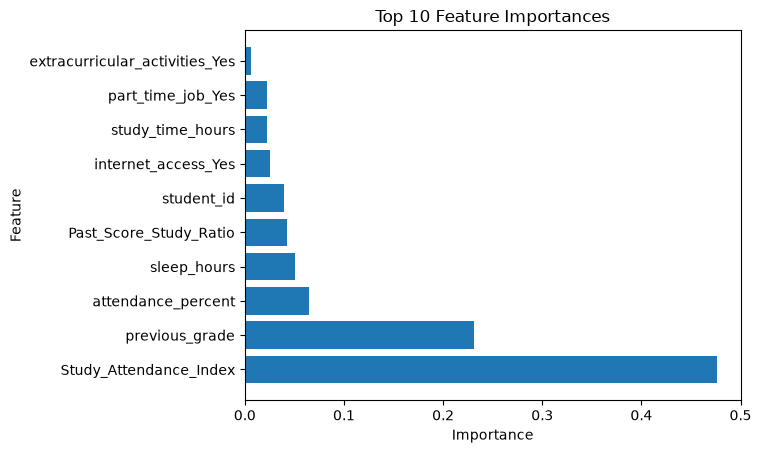

In [130]:
top_features = feature_importance.head(10)
plt.barh(top_features["Feature"],top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.show()

## Plot Analysis
The larger the importance value, the more the particular feature influenced the prediction of the Random Forest model.
If any of our newly engineered features is high up in the list, this indicates that the new feature was indeed useful to the model.
Top Feature: Study Attendance Index stands out from all others in the above graph as it holds an importance value of more than 0.48, showing how important this new feature is compared to all others in the predictive process.
Second-most Important Features: previous grade and attendance percent are the next most important features, beating standard features like sleep or study hour.
However: Feature importance doesn’t necessarily mean causality; the feature importance simply measures how useful the feature was to the model.

# Conclusion
## Some of the important things learned from this experiment today include:
**Feature Engineering**
In this case, we did not use just the original set of features but engineered new information from them.
Some of the feature engineered variables included:
- Study Attendance Index
- Past Score Study Ratio
- Study Level
**Hyperparameter Tuning**
GridSearchCV was used for the systematic search of good Random Forest parameters.
This method tests multiple parameter values through 5-fold cross-validation rather than selecting parameters manually.
**Model Comparison**
we compared:
- Untuned Random Forest
- Tuned Random Forest
Both models were evaluated using the same cross-validation metric.
## Important Concept
Feature engineering and hyperparameter tuning address two different problems:
- Feature Engineering provides improved information to the model.
- Hyperparameter Tuning provides better parameters to the model.